Notebook objective:
- make event plot figures for paper (figure 1 & figure 7)
- subanalysis for Analysis 3
- python version: 3.13.7

In [2]:
# imports 
import os, math, statistics, ast, random
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import itertools

### load transcripts & burstiness csv

In [ ]:
# read in transcript dataframes
df_A1 = pd.read_csv(f"{filepath}", sep = "\t", header=None)
df_A1 = df_A1.rename(columns={0: 'speaker', 1: 'cleaned_utt', 2: 'raw_utt', 3: 'start_ts', 4: 'stop_ts', 5: 'xds', 6: 'subtiers'})

df_A2 = pd.read_csv(f"{filepath}", sep = "\t", header=None)
df_A2 = df_A2.rename(columns={0: 'speaker', 1: 'cleaned_utt', 2: 'raw_utt', 3: 'start_ts', 4: 'stop_ts', 5: 'xds', 6: 'subtiers'})

df_A3 = pd.read_csv(f"{filepath}", sep = "\t", header=None)
df_A3 = df_A3.rename(columns={0: 'speaker', 1: 'cleaned_utt', 2: 'raw_utt', 3: 'start_ts', 4: 'stop_ts', 5: 'xds', 6: 'subtiers'})

df_B1 = pd.read_csv(f"{filepath}", sep = "\t", header=None)
df_B1 = df_B1.rename(columns={0: 'speaker', 1: 'cleaned_utt', 2: 'raw_utt', 3: 'start_ts', 4: 'stop_ts', 5: 'xds', 6: 'subtiers'})

df_B2 = pd.read_csv(f"{filepath}", sep = "\t", header=None)
df_B2 = df_B2.rename(columns={0: 'speaker', 1: 'cleaned_utt', 2: 'raw_utt', 3: 'start_ts', 4: 'stop_ts', 5: 'xds', 6: 'subtiers'})

transcript_dfs = [df_A1, df_A2, df_A3, df_B1,df_B2]
transcript_labels = ["A1", "A2", "A3","B1", "B2"]

In [7]:
COLOR_PAL_DICT = {'blue':'#0077BB', 'cyan': '#33BBEE', "teal": '#009988', 'orange':'#EE7733', 'red':'#CC3311', 'magenta':'#EE3377'}
COLOR_PAL_LIST = list(COLOR_PAL_DICT.values())
COLOR_PAL_DEF = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']

In [ ]:
# Read in Burstiness CSV 
combined_df = pd.read_csv(f"{"Burstiness values of all words in daylong recordings, NOTE: not public"}", sep="\t", na_values="NAN", header = 0)
combined_df['Interevent Intervals'] = combined_df['Interevent Intervals'].apply(lambda x: ast.literal_eval(x))
combined_df['Event Onsets'] = combined_df['Event Onsets'].apply(lambda x: ast.literal_eval(x))
df_daylong = combined_df.dropna()
df_daylong.loc[df_daylong['Frequency'] == 2, 'Burstiness'] = np.nan

In [10]:
def save_figure(fname = "", dpi = 600):
    plt.savefig(f"Burstiness/{fname}.png", dpi = 600)

def eventplot_acrosstranscripts(event_occurrences, event_label = "SET LABEL", save = False, fname = "" ):
    fig, ax = plt.subplots(figsize = (16,6), dpi = 500,facecolor ='w')
    y_ticks = [5.25, 4.0, 2.5, 1.25, 0.0]
    colors = COLOR_PAL_DEF[0:len(y_ticks)]
    ax.eventplot(positions = event_occurrences, lineoffsets=y_ticks, linelengths=0.8, 
                 colors = colors, alpha = 0.8)
    ax.set_yticks(ticks = y_ticks, labels = transcript_labels,
                fontweight = "bold", fontsize = 16)
    plt.setp(ax.get_xticklabels(), fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("time across recording (minute) ", fontweight = "bold", fontsize = 16)
    plt.title(f"Occurrences of {event_label} across recordings",fontweight = "bold", fontsize = 16)
    if save: save_figure(fname)
    plt.show()

def eventplot_acrosswords(df, words = [], colors = None, hline = True, right_yaxis = False, title = "", speech_color = "tab:blue", figsize = (9,6), wordlabels = [] ):
    yticks_positions =  [5.25, 3.75, 2.5, 1.25, -0.1]
    yticks_positions = yticks_positions[:len(words)+1]
    fig, ax = plt.subplots(figsize = figsize, dpi = 600) #og: (16,6); short: (9,6)
    if colors is None: 
        colors = COLOR_PAL_DEF
        random.shuffle(colors)
    else: colors = colors #[colors] * len(words)
    # first row is all speech (you)
    speech = df[df['Word'] == 'you']
    positions_speech =  np.array(speech["Event Onsets"].iloc[0]) / 60000
    ax.eventplot(positions_speech, color = speech_color, lineoffsets=yticks_positions[0])
    labels = [ "all\nspeech"] 
    for i, word in enumerate(words):
        df_word = df[df["Word"] == word]
        b_value = round(df_word.Burstiness.iloc[0],2)
        #print(df_word.Frequency.iloc[0])
        label = f'{wordlabels[i]}'#\n(B = {b_value})'
        labels.append(label)
        positions_word = np.array(df_word["Event Onsets"].iloc[0]) / 60000 
        ax.eventplot(positions_word, color = colors[i], lineoffsets=yticks_positions[i+1])
        
    ax.set_yticks(ticks = yticks_positions, labels = labels,
                  fontweight = "bold", fontsize = 16)
    #ax.set_xticks([])
    if hline is True: ax.axhline(y = 0.5, linestyle = "--", color = "black")
    #plt.setp(ax.get_xticklabels(), fontsize=14, fontweight='bold')
    ax.set_xticks([]) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("time across day", fontweight = "bold", fontsize = 13)
    if right_yaxis: 
        ax.yaxis.set_label_position("right")
        ax.yaxis.tick_right()
        ax.spines['right'].set_visible(True)
        ax.spines['left'].set_visible(False)
    plt.suptitle(f"{title}",fontweight = "bold", fontsize = 16)
    plt.tight_layout()
    plt.show()
    return


### Figure 1

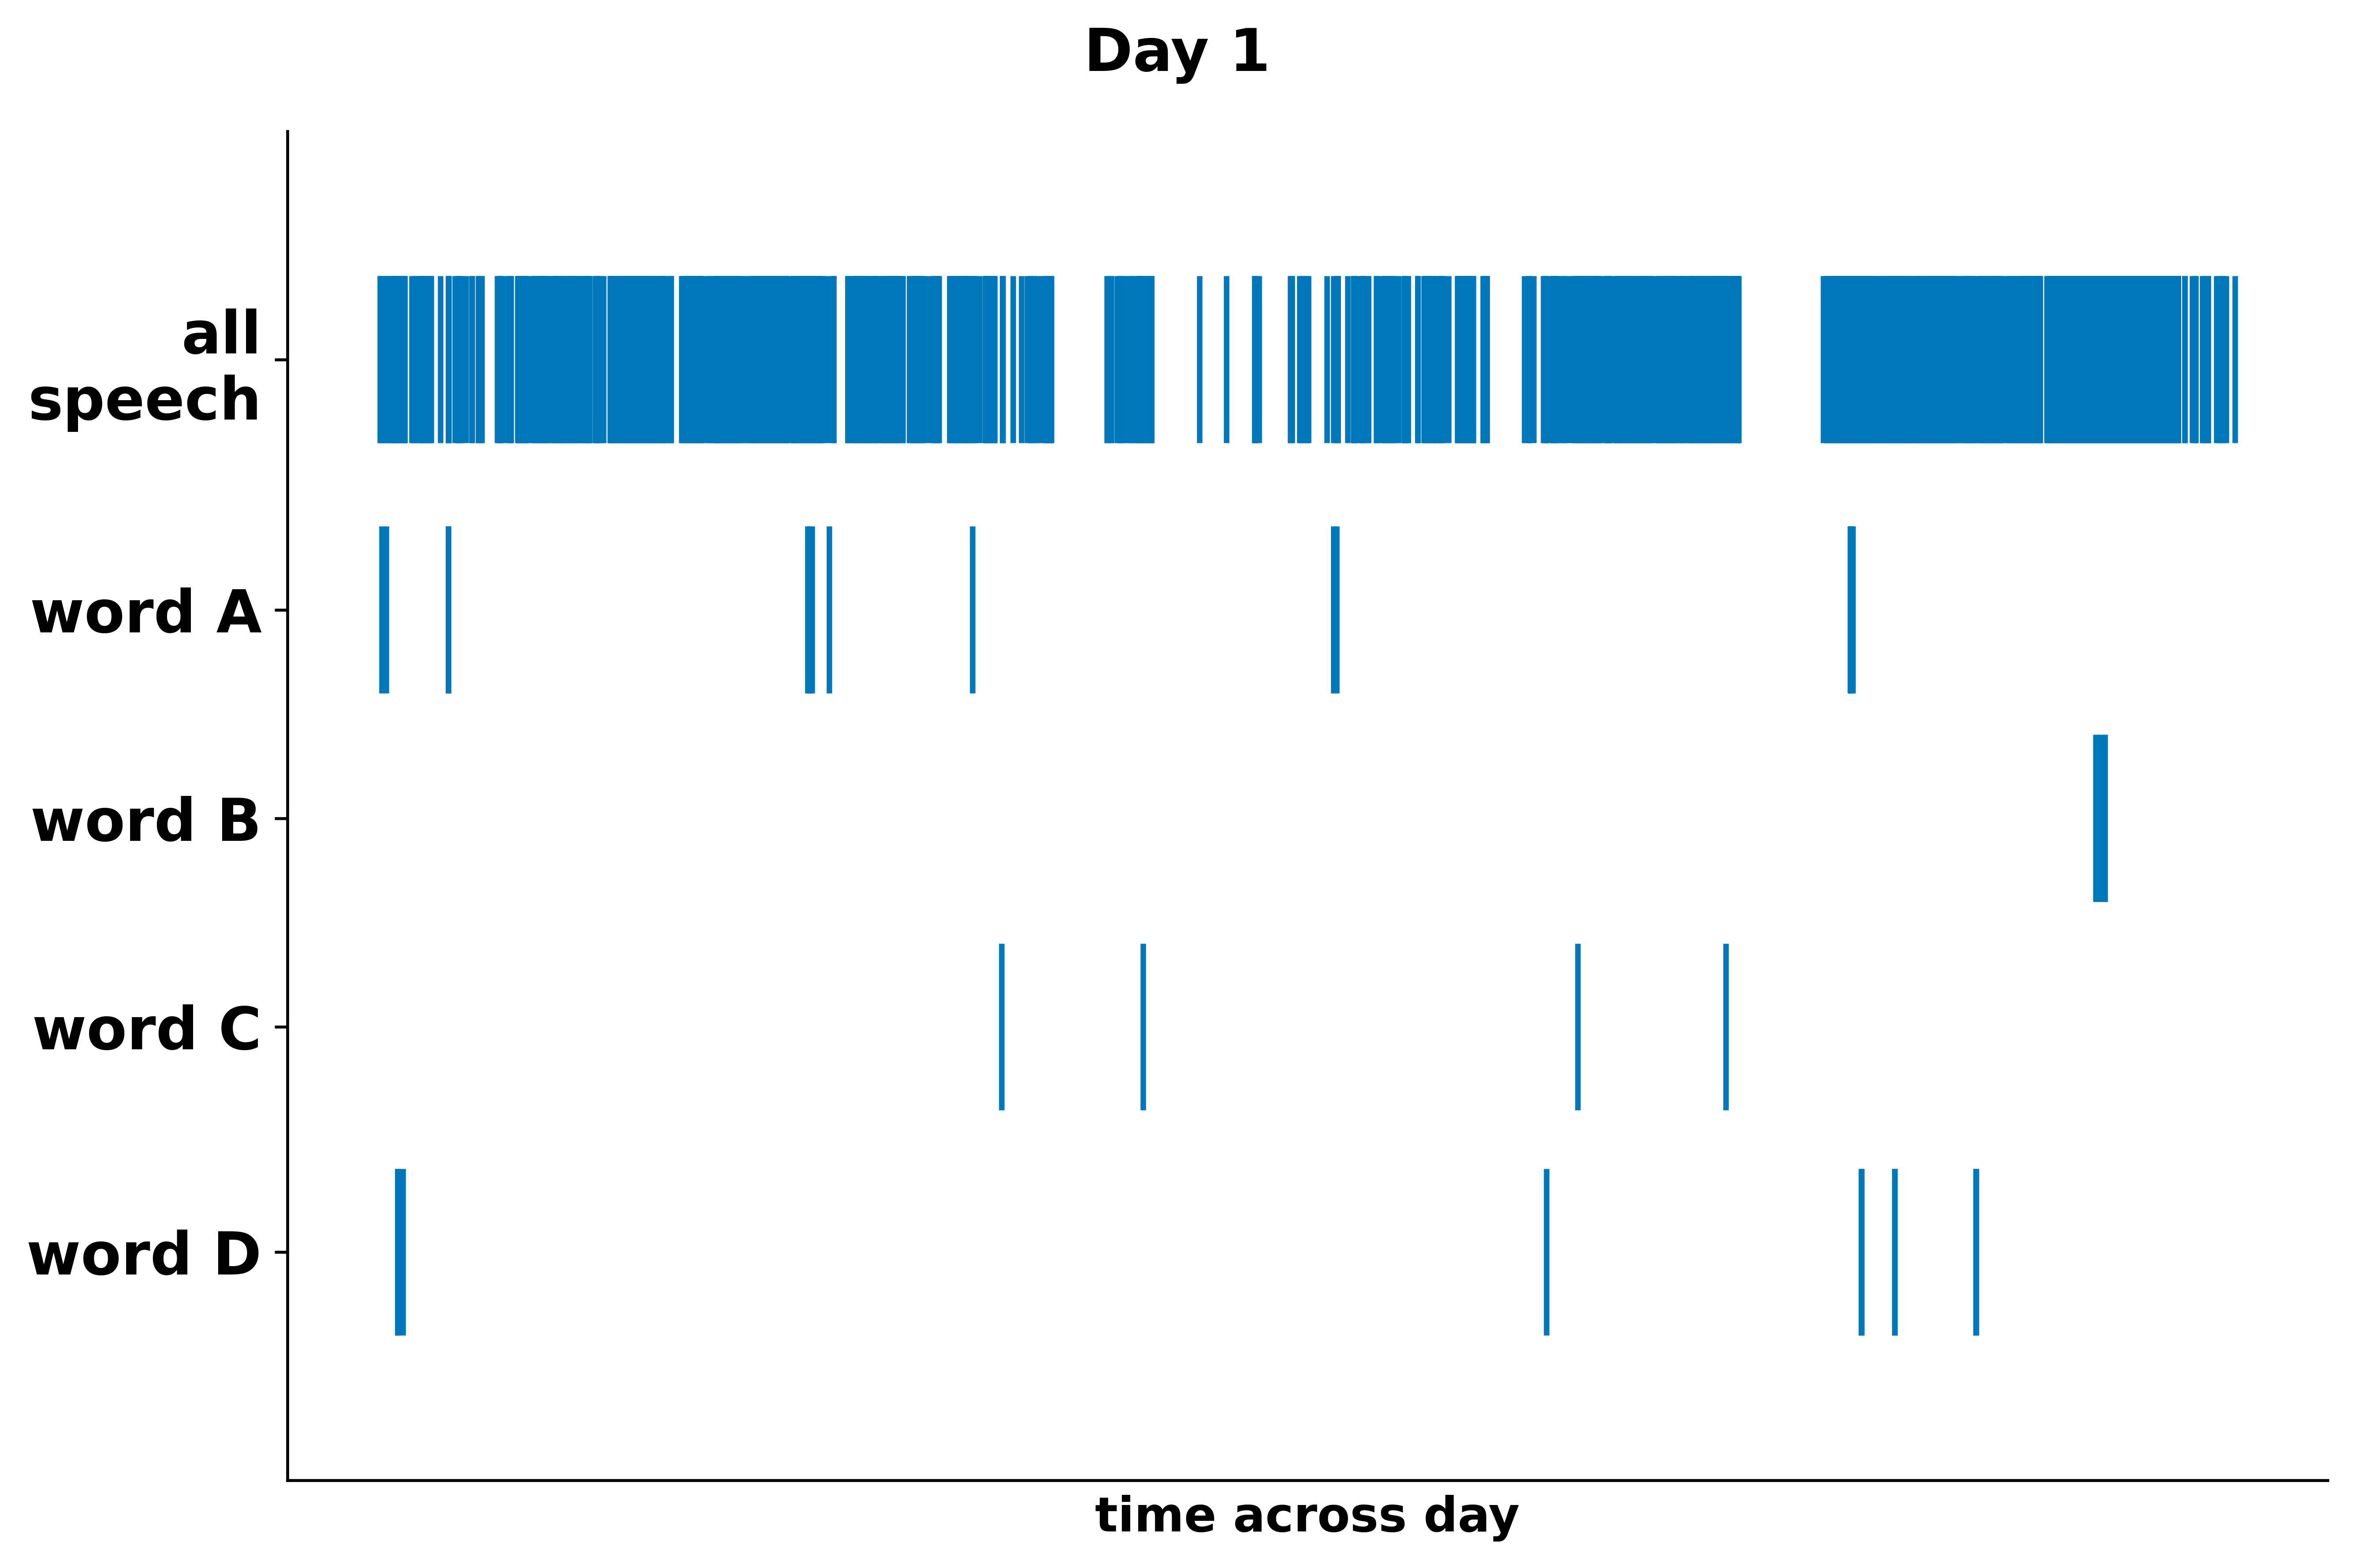

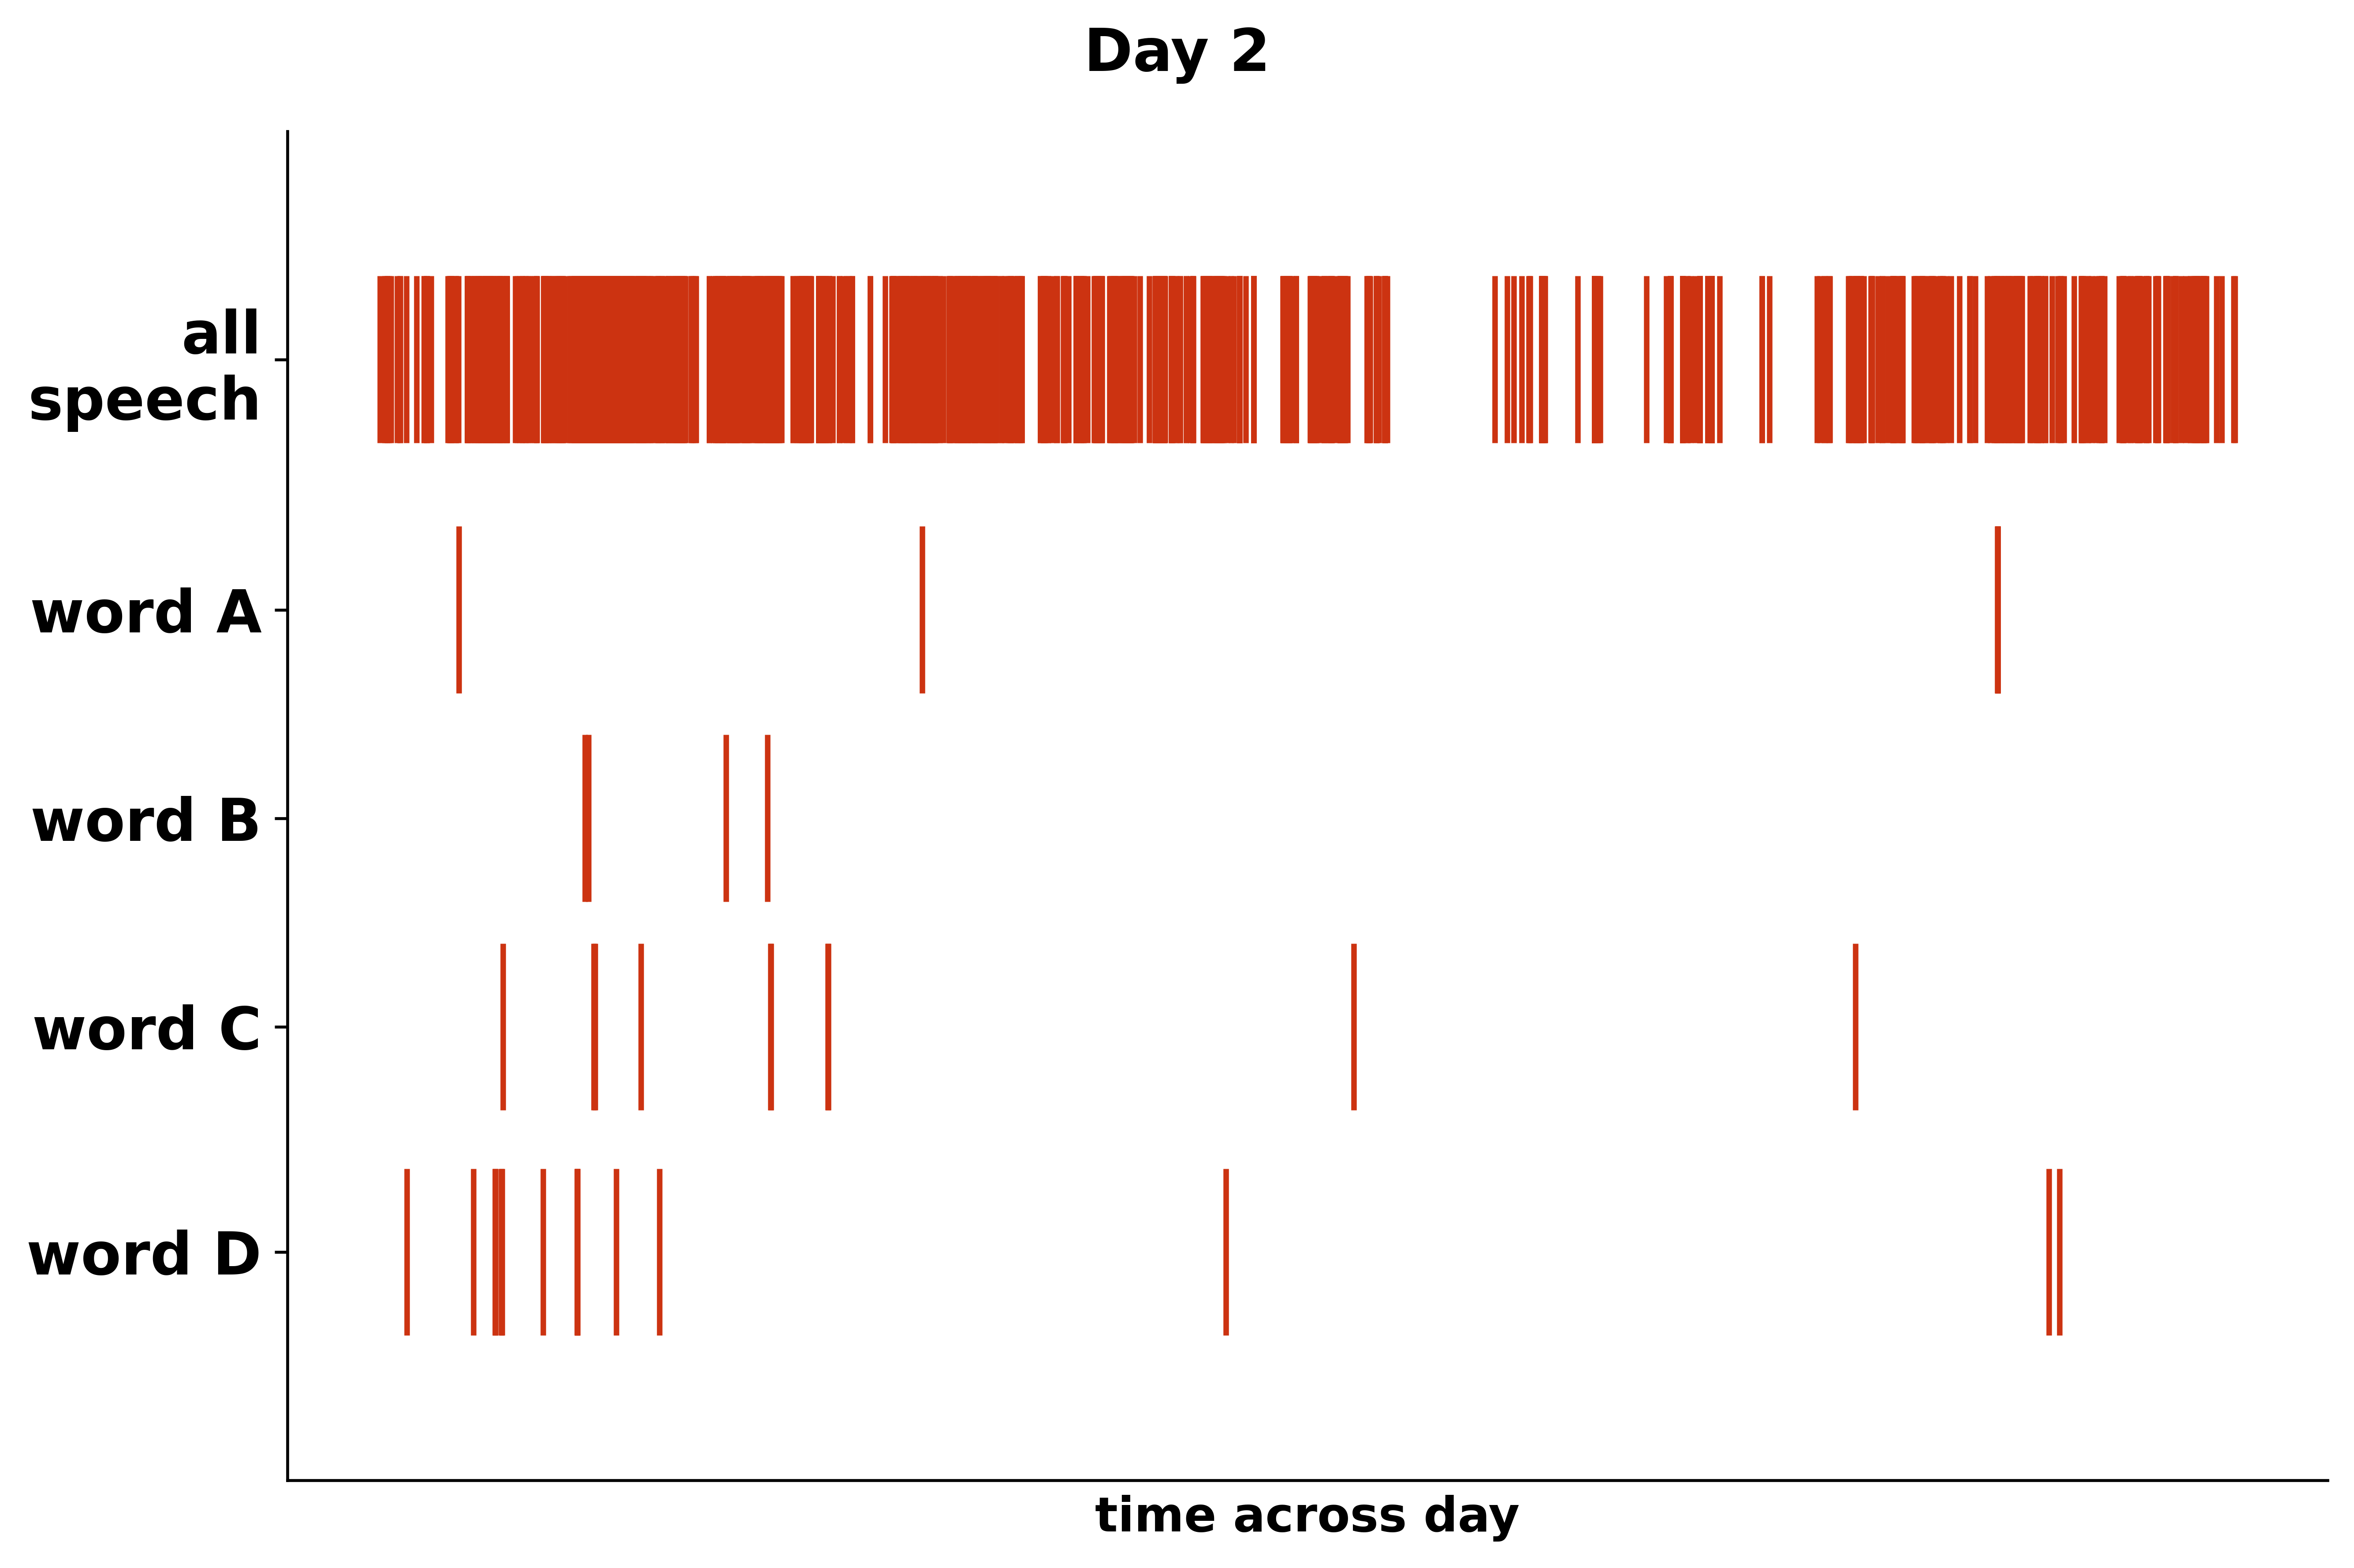

In [11]:
words = ["diaper", "plate", "lunch", "couch"]
wordlabels = ["word A", "word B", "word C", "word D"]
eventplot_acrosswords(df =  df_daylong[df_daylong["Transcript"] == "B1"], words = words, hline = False, title = "Day 1", colors = ["#0077BB"] * 4, speech_color = "#0077BB", wordlabels = wordlabels)
eventplot_acrosswords(df = df_daylong[df_daylong["Transcript"] == "B2"], words = words, hline = False, title = "Day 2", colors = ['#CC3311'] * 4, speech_color = '#CC3311', wordlabels=wordlabels)

### Figure 7

In [13]:
def eventplot_acrosswords2(df, words = [], colors = None, hline = True, right_yaxis = False, title = "", speech_color = "tab:blue", 
                           figsize = (9,6), wordlabels = []):
    yticks_positions =  np.arange(5.5,  -7,  -1.5).tolist()#[5.25, 3.75, 2.5, 1.25, 0, -1.5, -2.7, -3.75, -5.25]
    print(yticks_positions, len(yticks_positions))
    yticks_positions = yticks_positions[:len(words)+1]
    fig, ax = plt.subplots(figsize = figsize, dpi = 600) #og: (16,6); short: (9,6)
    if colors is None: 
        colors = COLOR_PAL_DEF
        random.shuffle(colors)
    else: colors = colors #[colors] * len(words)
    # first row is all speech (you)
    speech = df[df['Word'] == 'you']
    positions_speech =  np.array(speech["Event Onsets"].iloc[0]) / 60000
    ax.eventplot(positions_speech, color = speech_color, lineoffsets=yticks_positions[0])
    labels = [ "all\nspeech"]
    for i, word in enumerate(words):
        df_word = df[df["Word"] == word]
        b_value = round(df_word.Burstiness.iloc[0],2)
        f_value = df_word.Frequency.iloc[0]
        #print(df_word.Frequency.iloc[0])
        label = f'{wordlabels[i]}\n(B = {b_value})' # \nN = {f_value}'
        labels.append(label)
        positions_word = np.array(df_word["Event Onsets"].iloc[0]) / 60000 
        ax.eventplot(positions_word, color = colors[i], lineoffsets=yticks_positions[i+1])
        
    ax.set_yticks(ticks = yticks_positions, labels = labels,
                  fontweight = "bold", fontsize = 16)
    #ax.set_xticks([])
    if hline is True: ax.axhline(y = -1.2, linestyle = "--", color = "black")
    plt.setp(ax.get_xticklabels(), fontsize = 10)
    #ax.set_xticks([]) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("time across day", fontweight = "bold", fontsize = 13)
    if right_yaxis: 
        ax.yaxis.set_label_position("right")
        ax.yaxis.tick_right()
        ax.spines['right'].set_visible(True)
        ax.spines['left'].set_visible(False)
    plt.suptitle(f"{title}",fontweight = "bold", fontsize = 16)
    plt.tight_layout()
    plt.show()
    return 
def eventplot_interval(df, word,lowerbound = None, upperbound = None, color = "tab:orange"):

    # word 0 --> you (to show all speech)
    speech = df[df['Word'] == 'you']
    positions_speech =  np.array(speech["Event Onsets"].iloc[0]) / 60000

    if lowerbound is None and upperbound is None: 
        positions_speech = positions_speech  
    else: positions_speech = np.array([x for x in positions_speech if lowerbound <= x <= upperbound])

    # word 1 
    word1 = df[df['Word'] == word] 
    positions_word1 = np.array(word1["Event Onsets"].iloc[0]) / 60000 
    if lowerbound is None and upperbound is None:
        positions_word1 = np.array(word1["Event Onsets"].iloc[0]) / 60000 
    else:
        positions_word1 = np.array([x for x in positions_word1 if lowerbound <= x <= upperbound])
    fig, ax = plt.subplots(figsize = ((16,6)), dpi = 500)
    ax.eventplot(positions_speech, color = "tab:blue", lineoffsets=[5.5])
    ax.eventplot(positions_word1, color = color, lineoffsets=[4])
    ax.set_yticks(ticks = [4,5.5], labels = [ word, "all\nspeech"]
                , fontweight = "bold", fontsize = 16)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if lowerbound is None:
        ax.set_xlabel(f"\'{word}\' occurrences (daylong)", fontweight = "bold", fontsize = 16)
    else: ax.set_xlabel(f"\'{word}\' occurrences ({upperbound - lowerbound} minutes)", fontweight = "bold", fontsize = 16)
    plt.tight_layout()
    plt.show()



In [14]:
df = df_daylong
df = df[df["Transcript"] == "B1"]
# bursty words
words =  ["bucket", "water", "seven", "diaper" , "every", "working", "ladybugs", "cat" ]  
wordlabels = ["word A", "word B", "word C", "word D", "word E", "word F", "word G", "word H"]
colors = ["tab:orange", "tab:green", "tab:red", "tab:purple", "tab:pink", "tab:brown", "tab:olive", "tab:cyan"]
eventplot_acrosswords2(df = df, words = words, hline = True, right_yaxis=False, colors = colors, figsize=(16,10), wordlabels = wordlabels)


[5.5, 4.0, 2.5, 1.0, -0.5, -2.0, -3.5, -5.0, -6.5] 9


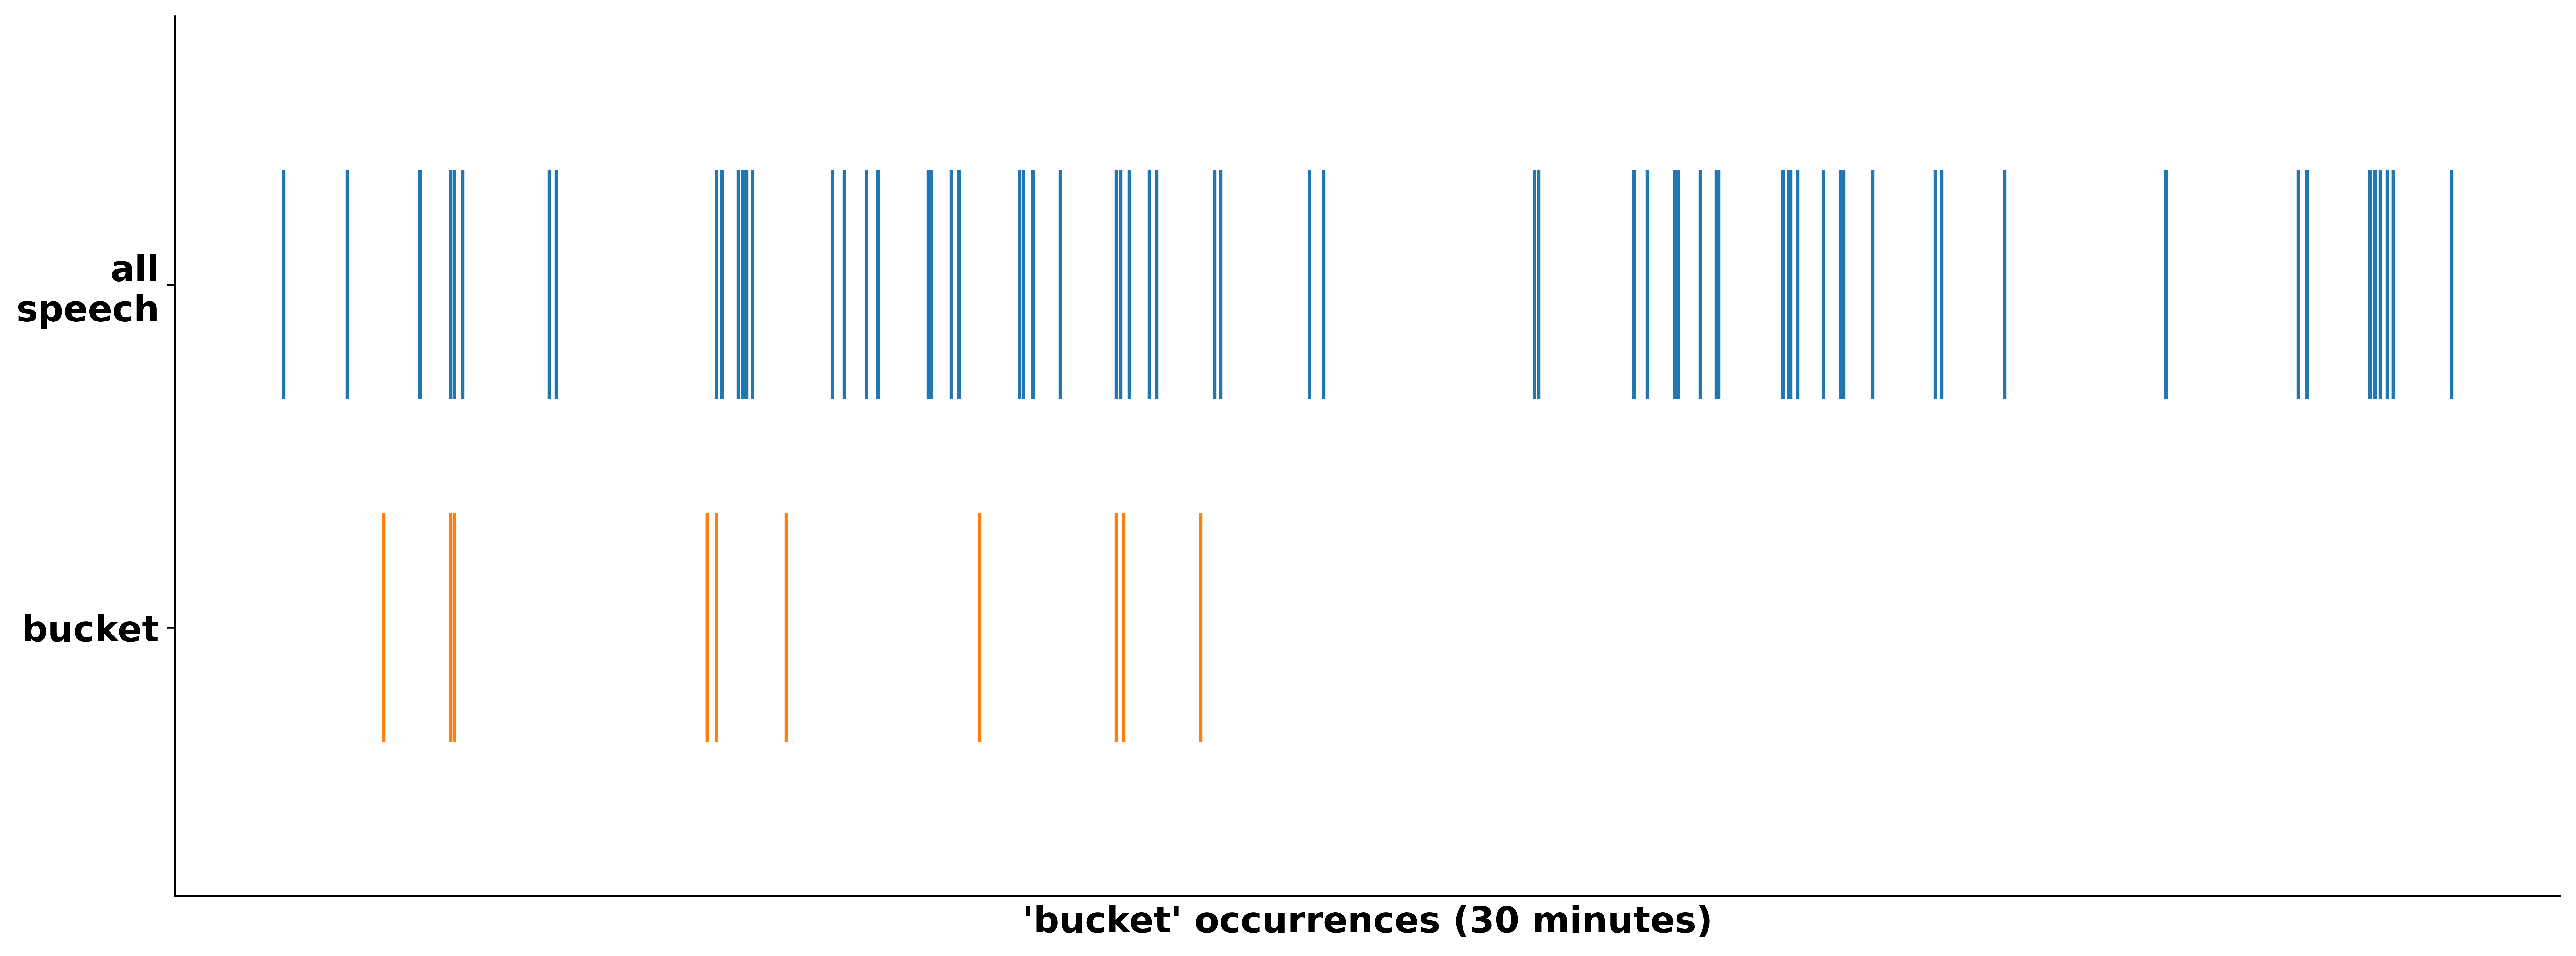

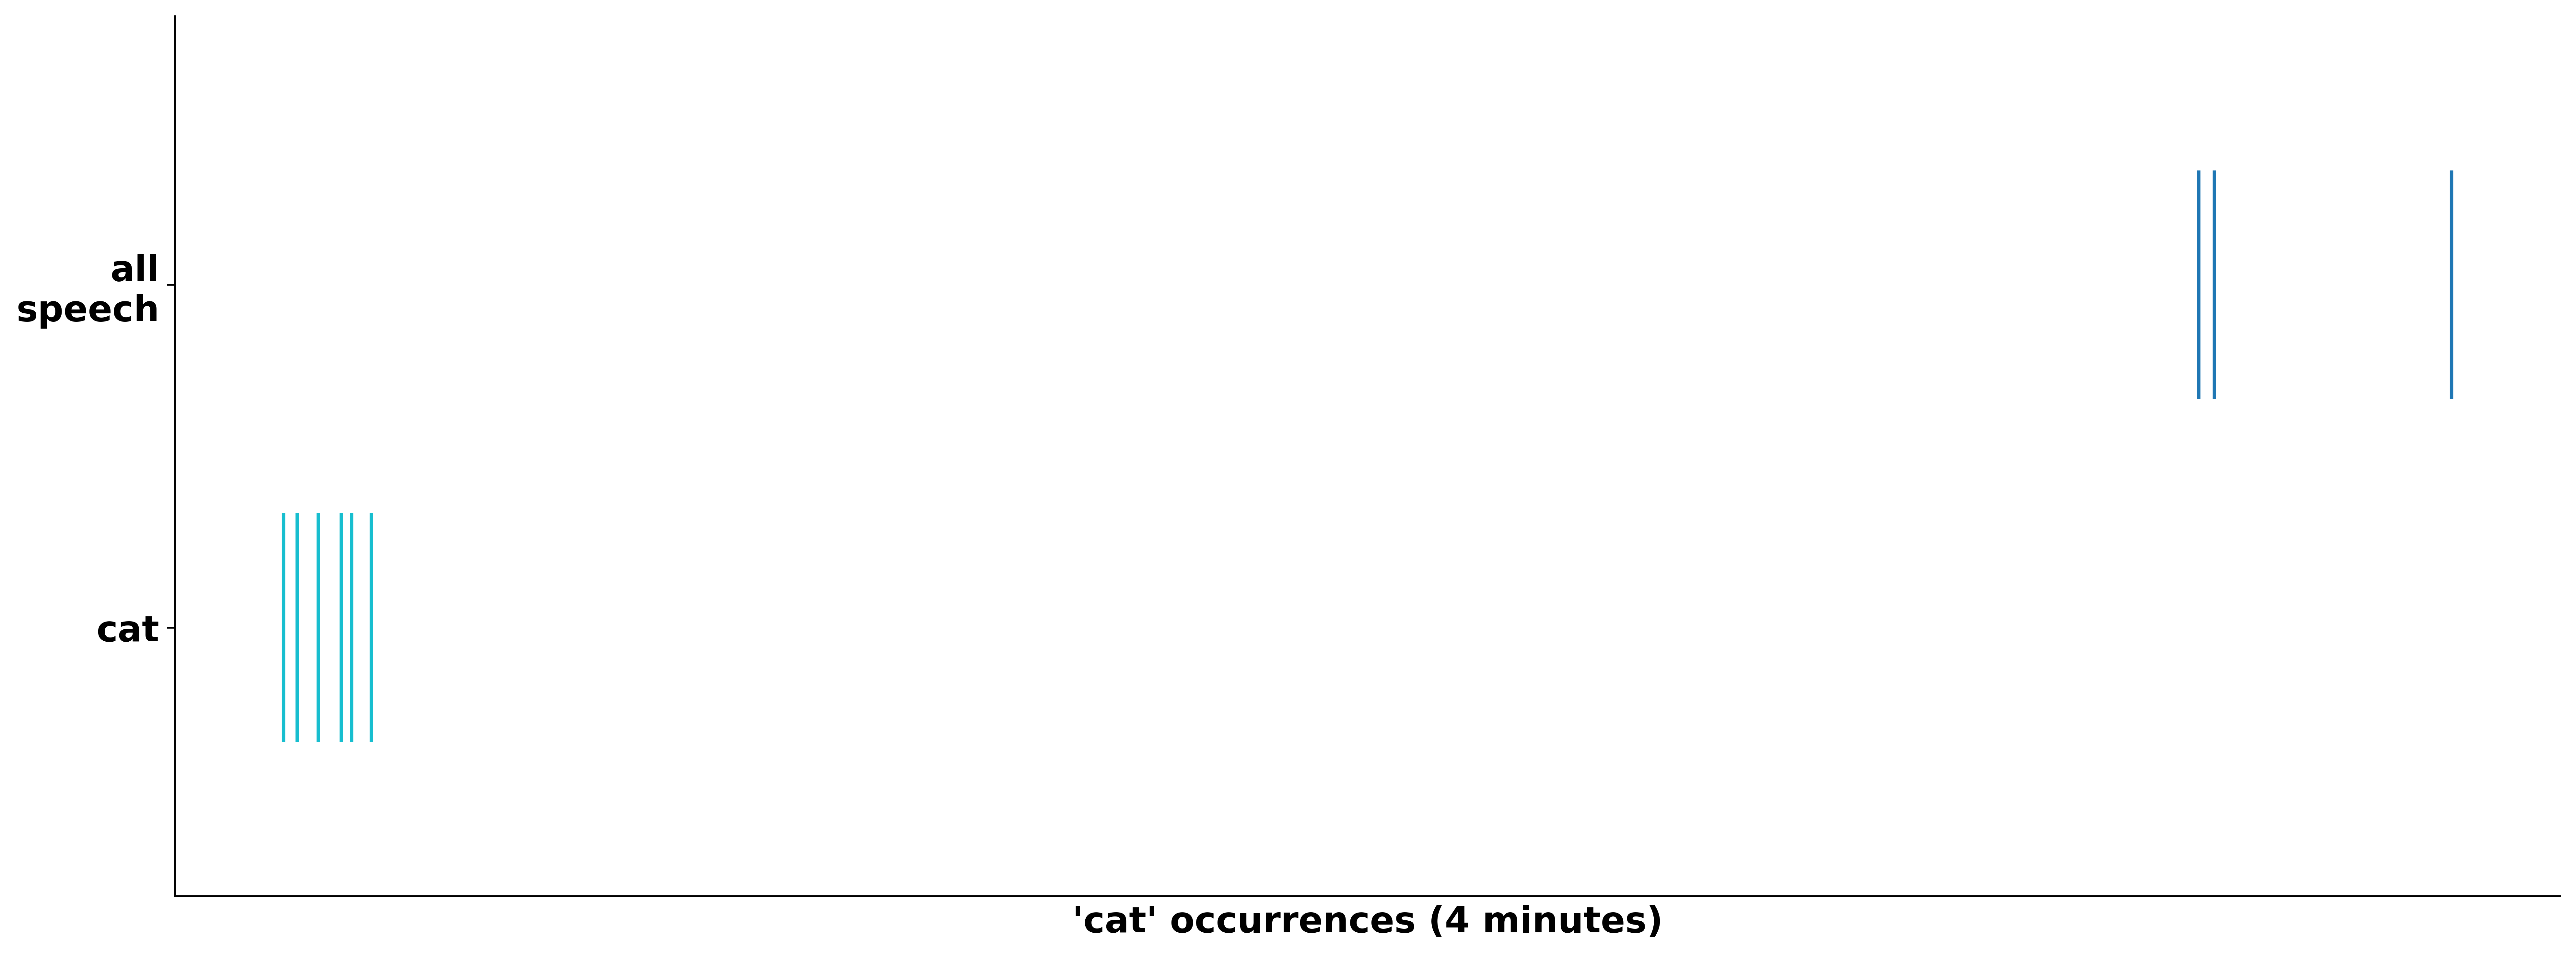

In [16]:
df = df_daylong[df_daylong["Transcript"] == "B1"]
eventplot_interval(df = df, lowerbound = 200, upperbound = 230, word = "bucket", color = "tab:orange")
eventplot_interval(df = df, lowerbound = 188, upperbound = 192, word = "cat", color = "tab:cyan")



## find "contradicting" B values
 - B values that are negatively bursty and clustered (like "ladybugs" and "Mister_Fish")

In [21]:
# find event span --> first event onset time - last event onset time 
def convert_to_min(value): #converts a time in ms to minutes 
    value = value / (60 *1000)
    return round(value, 3)
def get_span(val):
    eventspan = convert_to_min(val[-1] - val[0])
    #print(eventspan)
    return eventspan
df_daylong['Event Span'] = df_daylong['Event Onsets'].apply(get_span)

In [22]:
# filter words that are: negative bursty, and have an event span < 15 minutes 
df_burstiness_violation_neg = df_daylong[(df_daylong['Burstiness'] < 0) & (df_daylong['Event Span'] < 5)]
# filter words that are: positive bursty, and have an event span < 15 minutes
df_burstiness_violation_pos = df_daylong[(df_daylong['Burstiness'] > 0) & (df_daylong['Event Span'] < 5)]


In [23]:
df_burstiness_violation_neg.describe()

,Burstiness,Frequency,Event Span
count,265.000000,265.000000,265.000000
mean,-0.514389,3.871698,0.757691
std,0.304064,1.906565,0.968098
min,-0.999841,3.000000,0.028000
25%,-0.780025,3.000000,0.119000
50%,-0.552855,3.000000,0.263000
75%,-0.246620,4.000000,1.266000
max,-0.003293,24.000000,4.329000


In [ ]:
df_burstiness_violation_pos.describe()

,Burstiness,Frequency,Event Span
count,248.000000,248.000000,248.000000
mean,0.363445,4.939516,1.507952
std,0.208189,3.576856,1.393724
min,0.003846,3.000000,0.004000
25%,0.215198,3.000000,0.322500
50%,0.369148,4.000000,1.017500
75%,0.458220,6.000000,2.504500
max,0.922963,41.000000,4.926000


In [24]:
df_negbursty = df_daylong[df_daylong['Burstiness'] < 0 ]
df_posbursty = df_daylong[df_daylong['Burstiness'] > 0]
print("Prop of negatively bursty words (B < 0) that are context-bound:",len(df_burstiness_violation_neg)/len(df_negbursty))
print("Prop of positvely bursty words (B > 0) that are context-bound:",len(df_burstiness_violation_pos)/len(df_posbursty))

Prop of negatively bursty words (B < 0) that are context-bound: 0.2918502202643172
Prop of positvely bursty words (B > 0) that are context-bound: 0.05840791333019312
